In [1]:
import pandas as pd

# Files are right next to the notebook — no path needed!
q19 = pd.read_csv('Divvy_Trips_2019_Q1.csv')
q20 = pd.read_csv('Divvy_Trips_2020_Q1.csv')

# Quick peek: how many rows, and what columns?
print(q19.shape)
print(q19.columns.tolist())
print(q20.shape)
print(q20.columns.tolist())

(365069, 12)
['trip_id', 'start_time', 'end_time', 'bikeid', 'tripduration', 'from_station_id', 'from_station_name', 'to_station_id', 'to_station_name', 'usertype', 'gender', 'birthyear']
(426887, 13)
['ride_id', 'rideable_type', 'started_at', 'ended_at', 'start_station_name', 'start_station_id', 'end_station_name', 'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng', 'member_casual']


In [13]:
# Step 1: Rename 2019 columns to match 2020's names
q19_clean = q19.rename(columns={
    'trip_id': 'ride_id',
    'start_time': 'started_at',
    'end_time': 'ended_at',
    'from_station_name': 'start_station_name',
    'from_station_id': 'start_station_id',
    'to_station_name': 'end_station_name',
    'to_station_id': 'end_station_id',
    'usertype': 'member_casual'
})

# Step 2: Recode rider types so both years match (Subscriber = member, Customer = casual)
q19_clean['member_casual'] = q19_clean['member_casual'].replace({
    'Subscriber': 'member',
    'Customer': 'casual'
})

# Step 3: Merge both quarters into one dataframe
all_trips = pd.concat([q19_clean, q20], ignore_index=True)

# Check it worked
print(all_trips.shape)   # should be about (791956, ...)
print(all_trips['member_casual'].value_counts())   # member vs casual counts

(791956, 17)
member    720313
casual     71643
Name: member_casual, dtype: int64


In [14]:
# Step 1: Convert timestamps to proper date/time format
all_trips['started_at'] = pd.to_datetime(all_trips['started_at'], errors='coerce')
all_trips['ended_at'] = pd.to_datetime(all_trips['ended_at'], errors='coerce')

# Step 2: Create ride_length (in minutes) — how long each ride lasted
all_trips['ride_length_min'] = (all_trips['ended_at'] - all_trips['started_at']).dt.total_seconds() / 60

# Step 3: Create day_of_week (0 = Monday, 6 = Sunday) and month
all_trips['day_of_week'] = all_trips['started_at'].dt.dayofweek
all_trips['month'] = all_trips['started_at'].dt.to_period('M').astype(str)

# Step 4: Remove the dirty data
before = len(all_trips)   # remember the count BEFORE cleaning

all_trips = all_trips.dropna(subset=['started_at', 'ended_at', 'member_casual'])  # drop missing values
all_trips = all_trips[(all_trips['ride_length_min'] > 1) & (all_trips['ride_length_min'] < 1440)]  # drop <1min or >24hr rides

after = len(all_trips)   # count AFTER cleaning

print("Before cleaning:", before)
print("After cleaning:", after)
print("Removed:", before - after)


Before cleaning: 791956
After cleaning: 783803
Removed: 8153


In [15]:
# === ANALYSIS 1: Average ride length by rider type ===
print("=== Average ride length (minutes) ===")
print(all_trips.groupby('member_casual')['ride_length_min'].mean().round(1))

# === ANALYSIS 2: Median + max ride length ===
print("\n=== Median ride length (minutes) ===")
print(all_trips.groupby('member_casual')['ride_length_min'].median().round(1))

print("\n=== Longest ride (minutes) ===")
print(all_trips.groupby('member_casual')['ride_length_min'].max().round(1))

# === ANALYSIS 3: Rides by day of week (0=Mon, 6=Sun) ===
print("\n=== Number of rides by day of week ===")
print(all_trips.groupby(['day_of_week', 'member_casual'])['ride_id'].count())

# === ANALYSIS 4: Weekend share — what % of rides happen Sat/Sun? ===
all_trips['is_weekend'] = all_trips['day_of_week'] >= 5
print("\n=== Share of rides on weekends ===")
print(all_trips.groupby('member_casual')['is_weekend'].mean().round(3))

=== Average ride length (minutes) ===
member_casual
casual    38.5
member    11.5
Name: ride_length_min, dtype: float64

=== Median ride length (minutes) ===
member_casual
casual    23.2
member     8.5
Name: ride_length_min, dtype: float64

=== Longest ride (minutes) ===
member_casual
casual    1435.9
member    1433.1
Name: ride_length_min, dtype: float64

=== Number of rides by day of week ===
day_of_week  member_casual
0            casual             5558
             member           109855
1            casual             7266
             member           127363
2            casual             7623
             member           121302
3            casual             7085
             member           124568
4            casual             7954
             member           114588
5            casual            13399
             member            59033
6            casual            18512
             member            59697
Name: ride_id, dtype: int64

=== Share of rides on weeken

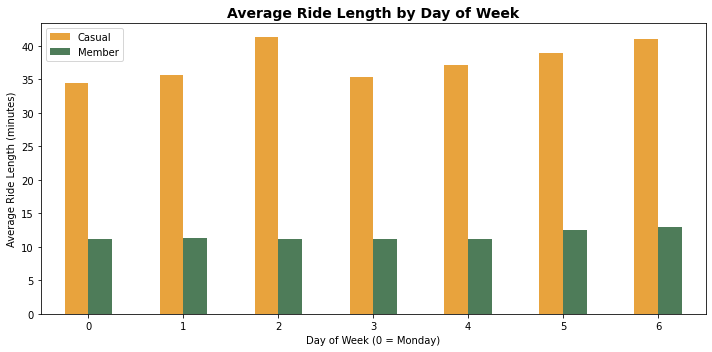

In [16]:
import matplotlib.pyplot as plt

days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

# === CHART 1: Average ride length by day of week ===
avg_by_day = all_trips.groupby(['day_of_week', 'member_casual'])['ride_length_min'].mean().unstack()

avg_by_day.plot(kind='bar', color=['#E8A33D', '#4E7C59'], figsize=(10, 5))
plt.title('Average Ride Length by Day of Week', fontsize=14, fontweight='bold')
plt.xlabel('Day of Week (0 = Monday)')
plt.ylabel('Average Ride Length (minutes)')
plt.legend(['Casual', 'Member'])
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('chart1_ride_length.png')   # saves the chart as an image
plt.show()

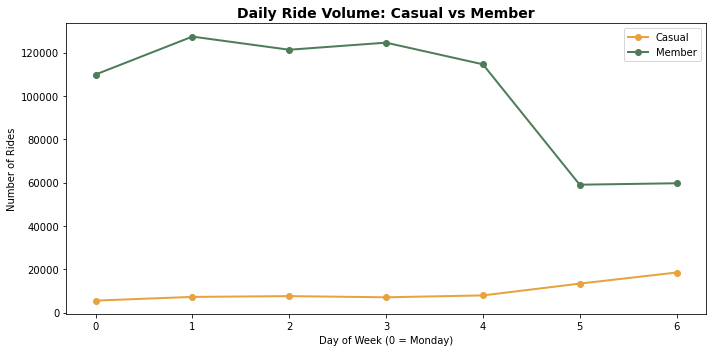

In [17]:
# === CHART 2: Number of rides by day of week ===
rides_by_day = all_trips.groupby(['day_of_week', 'member_casual'])['ride_id'].count().unstack()

rides_by_day.plot(kind='line', marker='o', color=['#E8A33D', '#4E7C59'], figsize=(10, 5), linewidth=2)
plt.title('Daily Ride Volume: Casual vs Member', fontsize=14, fontweight='bold')
plt.xlabel('Day of Week (0 = Monday)')
plt.ylabel('Number of Rides')
plt.legend(['Casual', 'Member'])
plt.tight_layout()
plt.savefig('chart2_daily_volume.png')
plt.show()